#Linear SVM

In [135]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


In [136]:
iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2) # Iris virginica

In [137]:
svm_clf = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1, random_state=42)
)

svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, random_state=42))])

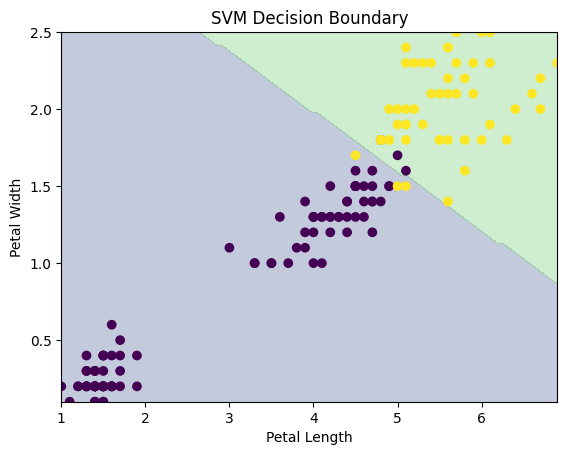

In [138]:
import numpy as np

# create grid
x0s = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x1s = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
x0, x1 = np.meshgrid(x0s, x1s)

X_grid = np.c_[x0.ravel(), x1.ravel()]
y_pred = svm_clf.predict(X_grid).reshape(x0.shape)

plt.contourf(x0, x1, y_pred, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("SVM Decision Boundary")
plt.show()

In [139]:
X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

In [140]:
svm_clf.decision_function(X_new)

array([ 0.66163816, -0.22035761])

#Nonlinear SVM

In [141]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

In [142]:
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

In [143]:
polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, max_iter=10000, random_state=42))])

#Kernel SVM - Polynomial Kernel

In [145]:
from sklearn.svm import SVC

In [146]:
poly_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly", degree=3, coef0=1, C=5)
)

poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

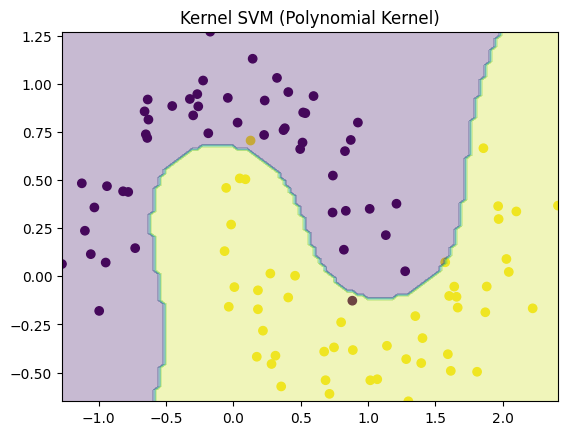

In [147]:
plt.scatter(X[:, 0], X[:, 1], c=y)

x0s = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x1s = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
x0, x1 = np.meshgrid(x0s, x1s)

X_grid = np.c_[x0.ravel(), x1.ravel()]
y_pred = poly_kernel_svm_clf.predict(X_grid).reshape(x0.shape)

plt.contourf(x0, x1, y_pred, alpha=0.3)

plt.title("Kernel SVM (Polynomial Kernel)")
plt.show()

#RBF SVM

In [148]:
rbf_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", gamma=5, C=0.001)
)

rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

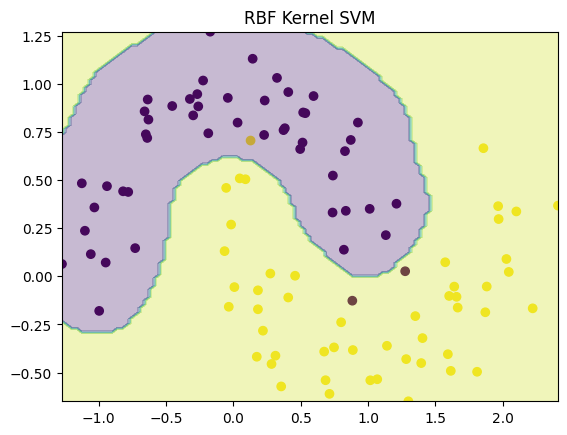

In [149]:
plt.scatter(X[:, 0], X[:, 1], c=y)

x0s = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x1s = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
x0, x1 = np.meshgrid(x0s, x1s)

X_grid = np.c_[x0.ravel(), x1.ravel()]
y_pred = rbf_kernel_svm_clf.predict(X_grid).reshape(x0.shape)

plt.contourf(x0, x1, y_pred, alpha=0.3)

plt.title("RBF Kernel SVM")
plt.show()

#SVM Regression

In [150]:
from sklearn.svm import LinearSVR

In [151]:
import numpy as np

# Generate a sample linear dataset
X = 2 * np.random.rand(100, 1) # 100 samples, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # Linear relationship with noise

svm_reg = make_pipeline(StandardScaler(),
                        LinearSVR(epsilon=0.5, random_state=42))
# For LinearSVR, y is typically expected to be a 1D array
svm_reg.fit(X, y.ravel())

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr', LinearSVR(epsilon=0.5, random_state=42))])

In [152]:
from sklearn.svm import SVR


In [153]:
import numpy as np

# Generate a sample quadratic dataset
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

svm_poly_reg = make_pipeline(StandardScaler(),
                            SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1))
svm_poly_reg.fit(X, y.ravel())

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=0.01, degree=2, kernel='poly'))])

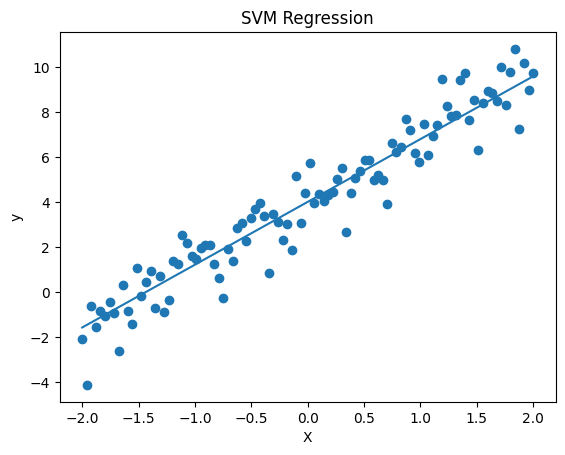

In [154]:
from sklearn.svm import LinearSVR

# Example dataset
X_reg = np.linspace(-2, 2, 100).reshape(-1, 1)
y_reg = 4 + 3 * X_reg[:, 0] + np.random.randn(100)

svm_reg = LinearSVR(epsilon=0.5, random_state=42)
svm_reg.fit(X_reg, y_reg)

y_pred = svm_reg.predict(X_reg)

plt.scatter(X_reg, y_reg)
plt.plot(X_reg, y_pred)

plt.title("SVM Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()